In [3]:
%pip install -U accelerate

Task: Sentiment Analysis
Domain: Movie Reviews
Dataset: IMDb
Model: bert-base-uncased
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\User\AppData\

Step,Training Loss
50,0.665899
100,0.540271
150,0.420666
200,0.420339
250,0.360056


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.360056,0.386692,250,0.824000,0.822314,0.815574,0.818930



Evaluation Results:
{'eval_loss': 0.3866920471191406, 'eval_accuracy': 0.824, 'eval_precision': 0.8223140495867769, 'eval_recall': 0.8155737704918032, 'eval_f1': 0.8189300411522634}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

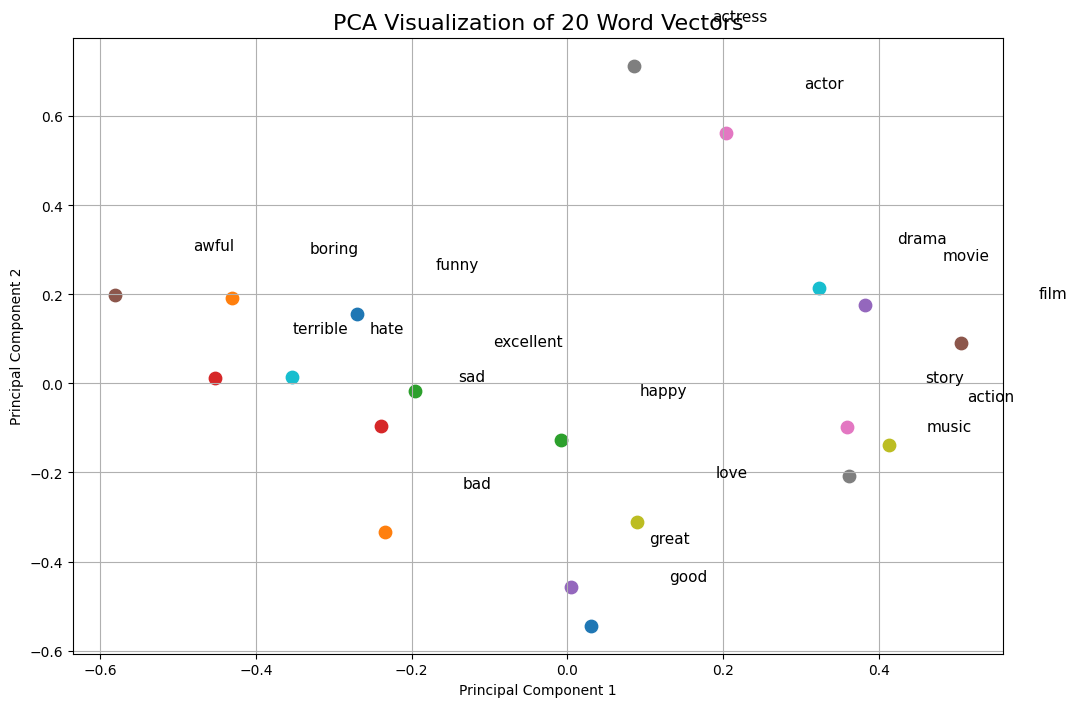

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.decomposition import PCA

print("Task: Sentiment Analysis")
print("Domain: Movie Reviews")
print("Dataset: IMDb")
print("Model: bert-base-uncased")


dataset = load_dataset("imdb")

# Use smaller samples for faster training
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset  = dataset["test"].shuffle(seed=42).select(range(1000))

print(train_dataset)
print(test_dataset)


model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='binary'
    )

    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

results = trainer.evaluate()
print("\nEvaluation Results:")
print(results)

trainer.save_model("./fine_tuned_bert_imdb")


embedding_matrix = model.bert.embeddings.word_embeddings.weight.detach().cpu().numpy()

# 20 Known Words
words = [
    "good","bad","happy","sad","movie",
    "film","actor","actress","love","hate",
    "funny","boring","excellent","terrible",
    "great","awful","story","music","action","drama"
]

vectors = []
labels = []

for word in words:
    token_id = tokenizer.convert_tokens_to_ids(word)

    if token_id != tokenizer.unk_token_id:
        vectors.append(embedding_matrix[token_id])
        labels.append(word)

vectors = np.array(vectors)

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)


plt.figure(figsize=(12,8))

for i, word in enumerate(labels):
    x = reduced_vectors[i,0]
    y = reduced_vectors[i,1]

    plt.scatter(x, y, s=80)
    plt.text(x+0.1, y+0.1, word, fontsize=11)

plt.title("PCA Visualization of 20 Word Vectors", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()